### import

In [1]:
#regular stuff
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from astropy.table import Table
import astropy.io.fits as fits
from scipy.optimize import least_squares, minimize

#MGE
from mgefit.mge_fit_sectors import mge_fit_sectors
from mgefit.mge_fit_sectors_regularized import mge_fit_sectors_regularized
from mgefit.find_galaxy import find_galaxy
from mgefit.sectors_photometry import sectors_photometry
from mgefit.mge_print_contours import mge_print_contours, _gauss2d_mge
from mgefit.mge_print_contours_twist import mge_print_contours_twist
from mgefit.sectors_photometry_twist import sectors_photometry_twist
from mgefit.mge_fit_sectors_twist import mge_fit_sectors_twist
from mgefit.mge_fit_1d import mge_fit_1d


#JAM
import jampy as jam

#DATA
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/')

from IO_data import extract_Pipe3d_data, extract_data

### data 

In [2]:
#DIRECTORIES
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'
master_table_fn = DATA_FOLDER + 'output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v2.fits'
dynpop_fn = DATA_FOLDER + '/dynpop/SDSSDR17_MaNGA_JAM.fits'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [3]:
master_table = Table.read(master_table_fn)
mastertable_dict = {}
for i in range(len(master_table)):
    mastertable_dict[master_table['plateifu'][i]] = i

master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [4]:
dynpop_1 = Table.read(dynpop_fn, hdu=1)
dynpop_sph = Table.read(dynpop_fn, hdu=5)
dynpop_cyl = Table.read(dynpop_fn, hdu=4)
dynpop_sph_MFL = Table.read(dynpop_fn, hdu=3)
dynpop_cyl_MFL = Table.read(dynpop_fn, hdu=2)
dynpop_dict = {}
for i in range(len(dynpop_1)):
    dynpop_dict[dynpop_1['plateifu'][i]] = i

dynpop_sph[:5]

inc_deg,beta_r,log_ML_stellar,log_rho_s,rs,kappa,log_Mt_Re,log_Ms_Re,log_Md_Re,fdm_Re,log_ML_dyn_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,log_Ms_rhalf,log_Md_rhalf,MW_Gt_Re,MW_Gs_Re,MW_Gd_Re,MW_Gt_rhalf,MW_Gs_rhalf,MW_Gd_rhalf,Gt_Re,Gs_Re,Gd_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
46.668,-2.778,-0.658,6.733940008672038,11.311,-0.744,9.591,8.432,9.56,0.931,0.502,0.02774,4.0724865751523165,9.551,8.414,9.518,1.237,2.249,1.162,1.237,2.194,1.162,-1.21,-2.244,-1.145
86.717,-0.499,0.821,0.6129400086720377,21.037,-0.691,9.972,9.972,3.972,0.0,0.821,0.024913,6.943609332555538,10.089,10.089,4.121,1.4,1.4,1.123,1.681,1.681,1.169,-1.025,-1.025,-1.092
2.775,-3.0,0.802,4.726940008672037,250.0,0.747,11.462,11.421,10.414,0.089,0.842,0.050367,2.6794080380797283,11.397,11.366,10.238,2.291,2.413,1.044,2.256,2.346,1.046,-2.319,-2.537,-1.052
86.222,-0.811,0.247,6.114940008672037,13.223,0.616,9.495,9.375,8.877,0.241,0.367,0.025732,4.032477836012196,9.558,9.426,8.977,1.795,2.003,1.14,1.827,2.072,1.137,-1.733,-1.972,-1.122
42.215,-2.529,0.207,4.392940008672038,47.909,1.255,10.235,10.213,8.927,0.049,0.229,0.021683,6.97977496827016,10.236,10.214,8.93,2.019,2.063,1.159,2.019,2.063,1.16,-1.934,-1.977,-1.107


### test gal

In [5]:
test_gal = '8486-3701'
m_idx = mastertable_dict[test_gal]
d_idx = dynpop_dict[test_gal]
plate = master_table['plate'][m_idx]
ifu = master_table['ifudsgn'][m_idx]
H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s
z = master_table['nsa_z'][m_idx]

In [6]:
master_table[m_idx]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

### maps

In [7]:
hdu = fits.open(DATA_FOLDER + '/DR17/' + str(plate) + '/' + ifu + '/manga-' + test_gal + '-LINCUBE.fits.gz')
rimg = hdu[13].data
vel_maps = extract_data(VEL_FOLDER, test_gal, ['star_sigma'])
star_sigma = vel_maps['star_sigma']

file_name = VEL_FOLDER + '/' + str(plate) + '/' + ifu + '/manga-' + test_gal + '-MAPS-HYB10-MILESHC-MASTARSSP.fits.gz'
cube = fits.open(file_name)
star_vel =  cube['STELLAR_VEL'].data
cube.close()

rfwhm=2.43751 # arsec
rfwhm_px = rfwhm / 0.5 # px

Text(0.5, 1.0, 'stellar velocity')

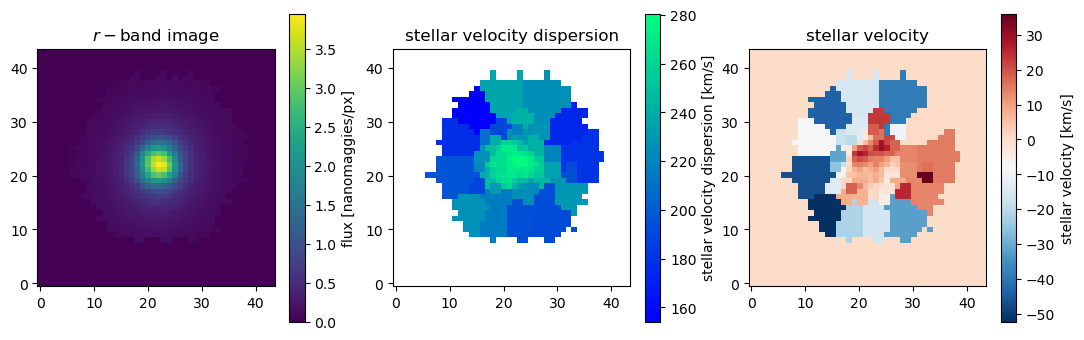

In [8]:
fig, ax = plt.subplots(1,3, figsize=(13,4))
im0 = ax[0].imshow(rimg)
plt.gca().invert_yaxis()
mstar_sigma = ma.array(star_sigma, mask=vel_maps['star_sigma_mask'])
im1 = ax[1].imshow(mstar_sigma, cmap='winter')
ax[0].invert_yaxis()
ax[1].invert_yaxis()
fig.colorbar(im0, label='flux [nanomaggies/px]')
ax[0].set_title(r'$r-$band image')
fig.colorbar(im1, label='stellar velocity dispersion [km/s]')
ax[1].set_title(r'stellar velocity dispersion')
im2 = ax[2].imshow(star_vel, cmap='RdBu_r')
ax[2].invert_yaxis()
fig.colorbar(im2, label='stellar velocity [km/s]')
ax[2].set_title(r'stellar velocity')


### convert broadband image to solar luminosities

In [9]:
def mag_conv(rimg, distance):

    M_sol_r = 4.65 #AB mag
    AB_img = 22.5 - 2.5*np.log10(rimg)

    # convert to abs mag
    AB_abs = AB_img - 5*np.log10(distance*1000*1000/10)

    L_img = 10**((M_sol_r - AB_abs)/2.5)
    return L_img

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_39257/2970439758.py:4: RuntimeWarning: divide by zero encountered in log10
  AB_img = 22.5 - 2.5*np.log10(rimg)


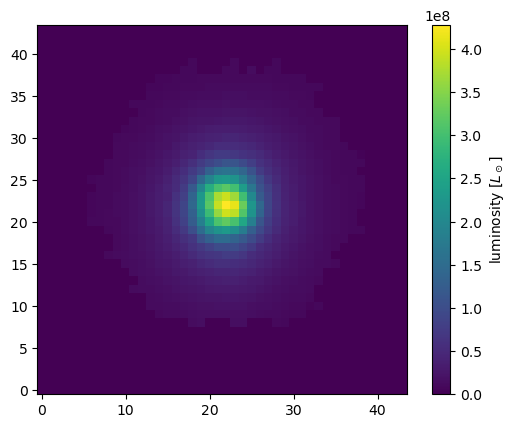

In [10]:
Limg = mag_conv(rimg, c*z/H_0)
plt.imshow(Limg)
plt.gca().invert_yaxis()
plt.colorbar(label=r'luminosity [$L_\odot$]')

## MGE

 Pixels used: 194
 Peak Img[j, k]: 22 22
 Mean (j, k): 21.99 21.99
 Theta (deg): 98.1
 Astro PA (deg): 171.9
 Eps: 0.114
 Major axis (pix): 8.3


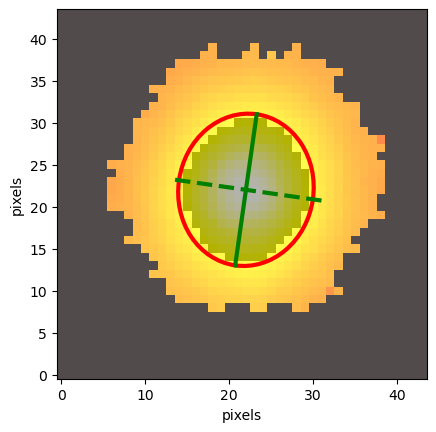

In [11]:
f = find_galaxy(Limg, fraction=0.1, plot=True)

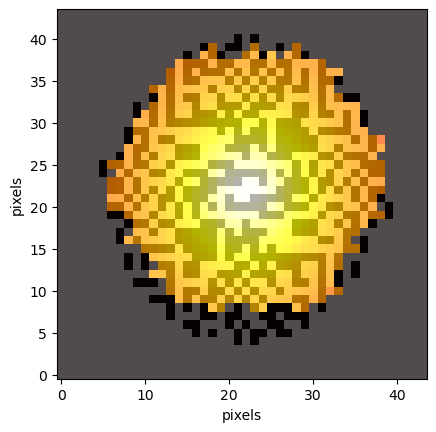

In [12]:
s = sectors_photometry(Limg, f.eps, f.theta, f.xpeak, f.ypeak,
                            plot=1, minlevel=6, #mask=sMass==0
                      )

Starting the LINEAR fit with  10000  Gaussians. Please wait...
Nonzero Gaussians: 7/10000
Eliminating not useful Gaussians...
ngauss: 6          chi2: 10.00
ngauss: 5          chi2: 10.00
ngauss: 4          chi2: 10.00
Starting nonlinear fit...
Iteration: 0  chi2: 10.00  Nonzero: 4/4
Iteration: 6  chi2: 9.990  Nonzero: 3/4
Nonzero Gaussians: 3/4
Eliminating not useful Gaussians...
Starting nonlinear fit...
Iteration: 0  chi2: 9.990  Nonzero: 3/3
Iteration: 3  chi2: 9.985  Nonzero: 3/3
Nonzero Gaussians: 3/3
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
  Computation time: 0.98 seconds
  Total Iterations:  0
 Nonzero Gaussians:  3
  Unused Gaussians:  9997
 Sectors used in the fit:  19
 Total number of points fitted:  256
 Chi2: 9.985 
 STDEV: 0.1936 
 MEANABSDEV: 0.1311 
############################################
  Total_Counts   sigma_Pixels     q_obs
############################################
   9.6417e+09        2.204 

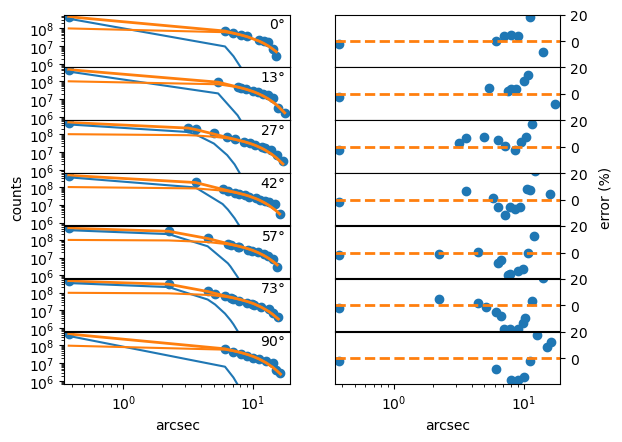

In [13]:
m = mge_fit_sectors_regularized(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, bulge_disk=0, linear=1, 
                    # sigmapsf=rfwhm_px, normpsf=1
                   )

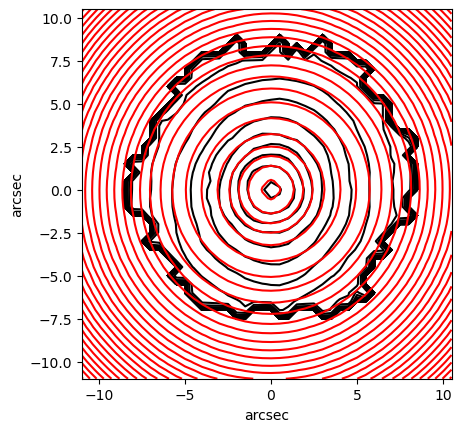

In [14]:
mge_print_contours(Limg, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.5,
                       # sigmapsf=rfwhm_px, normpsf=1, 
                   # binning=9, 
                       minlevel=0.1
                  )

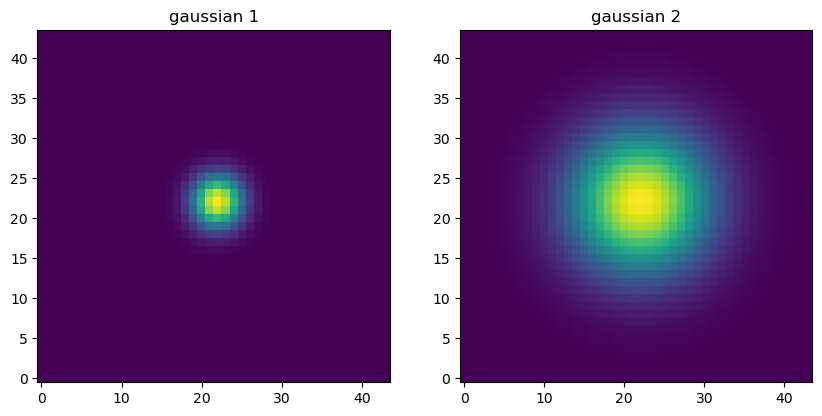

In [15]:
L, sigma, q_obs = m.sol
fig,ax = plt.subplots(1,len(L), figsize=(10,10))

for i in range(len(L)):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(rimg.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()

<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_39257/1452928647.py:12: SyntaxWarning: invalid escape sequence '\o'
  fig.colorbar(im0, label='MGE flux - MaNGA flux [$L_\odot$]')
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_39257/1452928647.py:9: RuntimeWarning: divide by zero encountered in divide
  im1 = ax[1].imshow((mge_flux - Limg)/Limg)


Text(0.5, 1.0, 'relative residual')

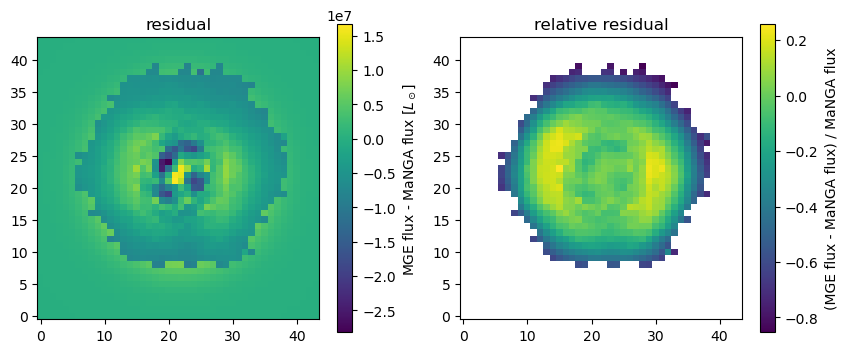

In [16]:
mge_flux =0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(rimg.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta)


fig, ax = plt.subplots(1,2, figsize=(10,4))
im0 = ax[0].imshow(mge_flux - Limg)
plt.gca().invert_yaxis()
im1 = ax[1].imshow((mge_flux - Limg)/Limg)
ax[0].invert_yaxis()
ax[1].invert_yaxis()
fig.colorbar(im0, label='MGE flux - MaNGA flux [$L_\odot$]')
ax[0].set_title(r'residual')
fig.colorbar(im1, label='(MGE flux - MaNGA flux) / MaNGA flux')
ax[1].set_title(r'relative residual')

## JAM

### rotate maps and remove center

In [17]:
#rotate coordinates
center = (f.xpeak, f.ypeak)
im_axis = np.linspace(0, len(rimg)-1, len(rimg))
dist_x, dist_y = im_axis - f.xpeak, im_axis-f.ypeak
xs, ys = np.meshgrid(dist_x, dist_y)

rot_xs = xs*np.cos(np.radians(f.pa)) - ys*np.sin(np.radians(f.pa)) # angle is confusing?
rot_ys = xs*np.sin(np.radians(f.pa)) + ys*np.cos(np.radians(f.pa))



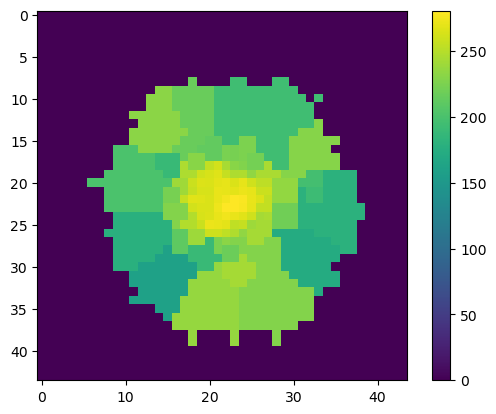

In [18]:
peak = np.ravel_multi_index((f.xpeak, f.ypeak), rimg.shape)
# sig = np.delete(vel_maps['star_sigma'], peak)
# xbin = np.delete(rot_xs.flatten(), peak)
# ybin = np.delete(rot_ys.flatten(), peak)



rms = np.sqrt(star_sigma**2 + star_vel**2)
plt.imshow(rms)
plt.colorbar()
# xbin = rot_xs
# ybin=rot_ys

xbin=rot_xs*0.5 # dist in arcsec

ybin=rot_ys*0.5

mask = np.logical_and(rms>0, xbin**2 + ybin**2 < 27)

xbin = xbin[mask]
ybin = ybin[mask]
rms = rms[mask]



### sph w halo

In [19]:
def JAM_sph_halo(params):

    rs, f_dm, b, inc= params
    
    inc=inc
    
    sigma_a = np.array(sigma*0.5) #px-->arcsec
    sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Msun/px^2 --> Msun/pc^2
    
    
    qobs = np.array(q_obs)
    
    distance = c*z/H_0
    mbh = 0         # Black hole mass in solar masses
    
    beta = np.full_like(surf, b
                       )
   
    
    surf_lum = surf_pot = surf
    sigma_lum = sigma_pot = sigma_a
    qobs_lum = qobs_pot = qobs
    
    sigmapsf = rfwhm
    normpsf = 1
    pixsize = 0.5
    # goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins
    
    
    
    # # first do MGE for halo
    m = MGE_NFW(rs) # in terms of pc
    
    #unpack halo sol
    surf_dm, sigma_dm = m.sol           # Peak surface density (Msun/pc**3) and sigma (pc)
    qobs_dm = np.ones_like(surf_dm)


    sigma_dm_a = np.arctan(sigma_dm / (c*z) * H_0 /1000 /1000)*60*60*180/np.pi

    # sigma_dm_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_dm*pixsize*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    
    # surf_dm = dens_dm * np.sqrt(2*np.pi)*sigma_dm  # (Msun/px**2) --> (Msun/pc**2)



    
    # sigma_dm = sigma_dm*pixsize #(px--> arcsec)
    
    reff = jam.mge.half_light_radius(surf_lum, sigma_lum, qobs_lum, distance=distance)[0] # half light radius from stellar map MGE in arcsec
    stars_lum_re = jam.mge.radial_mass(surf_lum, sigma_lum, qobs_lum, inc, reff) # stellar mass within re
    dark_mass_re = jam.mge.radial_mass(surf_dm, sigma_dm, qobs_dm, inc, reff) # dm mass within re
    
    f_dm=f_dm
    scale = (f_dm*stars_lum_re)/(dark_mass_re*(1 - f_dm))
    
    surf_pot = np.append(surf_lum, surf_dm*scale)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = np.append(sigma_lum, sigma_dm)      # Gaussian dispersion in arcsec
    qobs_pot = np.append(qobs_lum, qobs_dm)
    
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                               inc, mbh, distance, xbin, ybin, plot=1, pixsize=pixsize, pixang=0,
                       sigmapsf=sigmapsf, normpsf=normpsf,
                           beta=beta, moment='zz', quiet=0, 
                            align='sph', data=rms,
                       ml=None, logistic=False)
        

    return out.chi2



### sph no halo

In [ ]:
def JAM_sph(params):

    ml= params
    b = dynpop_sph_MFL['beta_r'][d_idx]
    inc = dynpop_sph_MFL['inc_deg'][d_idx]
    
    sigma_a = np.array(sigma*0.5) #px-->arcsec
    sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Msun/px^2 --> Msun/pc^2
    
    
    qobs = np.array(q_obs)
    
    distance = c*z/H_0
    mbh = 0         # Black hole mass in solar masses
    
    beta = np.full_like(surf, b
                       )
   
    
    surf_lum = surf_pot = surf*ml
    sigma_lum = sigma_pot = sigma_a
    qobs_lum = qobs_pot = qobs
    
    sigmapsf = rfwhm
    normpsf = 1
    pixsize = 0.5
    # goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins
    
    
    
    surf_pot = surf_lum   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    # surf_pot = np.append(surf_lum, surf_dm)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = sigma_lum     # Gaussian dispersion in arcsec
    qobs_pot = qobs_lum
    
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                               inc, mbh, distance, xbin, ybin, plot=1, pixsize=pixsize, pixang=0,
                       sigmapsf=sigmapsf, normpsf=normpsf,
                           beta=beta, moment='zz', quiet=0, 
                            align='sph', data=rms, ml=1, logistic=False)
        

    return out.model

### sph halo with density

In [338]:
def JAM_sph_halo_density():

    # rs, ps, b, inc, stellar_ml= params
    rs = 1000*dynpop_sph[d_idx]['rs'] # pc
    ps = (10**dynpop_sph[d_idx]['log_rho_s']) * (1/1000)**3 # Msun / pc**3
    b = dynpop_sph[d_idx]['beta_r']
    inc = dynpop_sph[d_idx]['inc_deg']
    fdm = dynpop_sph[d_idx]['fdm_Re']
    # stellar_ml = params
    
    inc=inc
    
    sigma_a = np.array(sigma*0.5) #px-->arcsec
    sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Msun/px^2 --> Msun/pc^2
    
    
    qobs = np.array(q_obs)
    
    distance = c*z/H_0
    mbh = 0         # Black hole mass in solar masses
    
    beta = np.full_like(surf, b
                       )
   
    
    surf_lum = surf_pot = surf
    sigma_lum = sigma_pot = sigma_a
    qobs_lum = qobs_pot = qobs
    
    sigmapsf = rfwhm
    normpsf = 1
    pixsize = 0.5
    # goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins
    
    
    
    # # first do MGE for halo
    m = MGE_NFW(rs) # in terms of Msun/pc**3 pc
    
    #unpack halo sol
    dens_dm, sigma_dm = m.sol           # Peak density (Msun/pc**3) and sigma (pc)
    qobs_dm = np.ones_like(dens_dm)

    # surf_dm = dens_dm * np.sqrt(2*np.pi)*sigma_dm # peak_surface_density (Msun/pc**2)

    # sigma_dm_a = np.arctan(sigma_dm / (c*z) * H_0 /1000 /1000)*60*60*180/np.pi

    # sigma_dm_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_dm*pixsize*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    
    # surf_dm = dens_dm * np.sqrt(2*np.pi)*sigma_dm  # (Msun/px**2) --> (Msun/pc**2)



    
    # sigma_dm = sigma_dm*pixsize #(px--> arcsec)
    
    reff = jam.mge.half_light_radius(surf_lum, sigma_lum, qobs_lum, distance=distance)[0] # half light radius from stellar map MGE in arcsec
    stars_lum_re = jam.mge.radial_mass(surf_lum, sigma_lum, qobs_lum, inc, reff) # stellar mass within re
    dark_mass_re = jam.mge.radial_mass(surf_dm, sigma_dm, qobs_dm, inc, reff) # dm mass within re
    
    f_dm=fdm
    scale = (f_dm*stars_lum_re)/(dark_mass_re*(1 - f_dm))
    
    surf_pot = np.append(surf_lum, surf_dm*scale)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = np.append(sigma_lum, sigma_dm_a)      # Gaussian dispersion in arcsec
    qobs_pot = np.append(qobs_lum, qobs_dm)
    
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                               inc, mbh, distance, xbin, ybin, plot=1, pixsize=pixsize, pixang=0,
                       sigmapsf=sigmapsf, normpsf=normpsf,
                           beta=beta, moment='zz', quiet=0, 
                            align='sph', data=rms, ml=None, logistic=False)
        

    return out.chi2

### MGE for halo

In [340]:
def MGE_NFW_density(ps,rs):

    r = np.geomspace(1,rs*10,300)
    rho = ps*(r/rs)**-1 * (0.5 + 0.5*r/rs)**-2

    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)
    return m
    


def MGE_NFW(rs):

    r = np.geomspace(1,rs*10,300)
    rho = (r/rs)**-1 * (0.5 + 0.5*r/rs)**-2

    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)
    return m

### cyl no halo

In [344]:
def JAM_cyl(params):

    b, inc = params
    
    # b = dynpop_sph_MFL['beta_r'][d_idx]
    # inc = dynpop_sph_MFL['inc_deg'][d_idx]
    
    sigma_a = np.array(sigma*0.5) #px-->arcsec
    sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Msun/px^2 --> Msun/pc^2
    
    
    qobs = np.array(q_obs)
    
    distance = c*z/H_0
    mbh = 0         # Black hole mass in solar masses
    
    beta = np.full_like(surf, b
                       )
   
    
    surf_lum = surf_pot = surf*ml
    sigma_lum = sigma_pot = sigma_a
    qobs_lum = qobs_pot = qobs
    
    sigmapsf = rfwhm
    normpsf = 1
    pixsize = 0.5
    # goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins
    
    
    
    surf_pot = surf_lum   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    # surf_pot = np.append(surf_lum, surf_dm)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = sigma_lum     # Gaussian dispersion in arcsec
    qobs_pot = qobs_lum
    
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                               inc, mbh, distance, xbin, ybin, plot=1, pixsize=pixsize, pixang=0,
                       sigmapsf=sigmapsf, normpsf=normpsf,
                           beta=beta, moment='zz', quiet=0, 
                            align='cyl', data=rms, ml=None, logistic=False)
        

    return out.model

### cyl w halo

In [412]:
def JAM_cyl_halo(params):

    rs, f_dm, b, inc, lg_ml= params
    
    inc=90
    distance=c*z/H_0
    rs =rs/(distance*np.pi/0.648) # pc --> arcsec
    
    sigma_a = np.array(sigma*0.5) #px-->arcsec
    sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Lsun/px^2 --> Lsun/pc^2
    
    
    qobs = np.array(q_obs)
    mbh = 0         # Black hole mass in solar masses
    
    beta = np.full_like(surf, b
                       )
   
    
    surf_lum = surf_pot = surf
    sigma_lum = sigma_pot = sigma_a
    qobs_lum = qobs_pot = qobs
    
    sigmapsf = rfwhm
    normpsf = 1
    pixsize = 0.5
    # goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins
    
    
    
    # # first do MGE for halo
    m = MGE_NFW(rs) # in terms of arcsec
    
    #unpack halo sol
    surf_dm, sigma_dm = m.sol           # Peak surface density (Msun/arcsec**3) and sigma (arcsec)
    qobs_dm = np.ones_like(surf_dm)

    
    reff = jam.mge.half_light_radius(surf_lum, sigma_lum, qobs_lum)[0] # half light radius from stellar map MGE in arcsec
    stars_lum_re = jam.mge.radial_mass(surf_lum, sigma_lum, qobs_lum, inc, reff) # stellar mass within re
    dark_mass_re = jam.mge.radial_mass(surf_dm, sigma_dm, qobs_dm, inc, reff) # dm mass within re
    
    f_dm=f_dm
    scale = (f_dm*stars_lum_re)/(dark_mass_re*(1 - f_dm))
    
    surf_pot = np.append(surf_lum, surf_dm*scale)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = np.append(sigma_lum, sigma_dm)      # Gaussian dispersion in arcsec
    qobs_pot = np.append(qobs_lum, qobs_dm)

    surf_pot *= 10**lg_ml
    
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                               inc, mbh, distance, xbin, ybin, plot=1, pixsize=pixsize, pixang=0,
                       sigmapsf=sigmapsf, normpsf=normpsf,
                           beta=beta, moment='zz', quiet=0, 
                            align='cyl', data=rms,
                       ml=1, logistic=False)
        

    return out



### tests

In [347]:
dynpop_cyl_MFL[d_idx]

inc_deg,beta_z,log_ML_dyn,kappa,log_Mt_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,MW_Gt_Re,MW_Gt_rhalf,Gt_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
8.532,0.0,0.826,-2.596,11.488,0.066701,3.6551516008157243,11.49,2.35,2.351,-2.387


jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.05
analytic_los=1 logistic=0 constant_anisotropy=1
inc=8.53; beta[0]=0.0; kappa=1.00; M/L=1.94e+09; BH=0.0; chi2/DOF=5.16
Total mass MGE (MSun): 4.933e+11



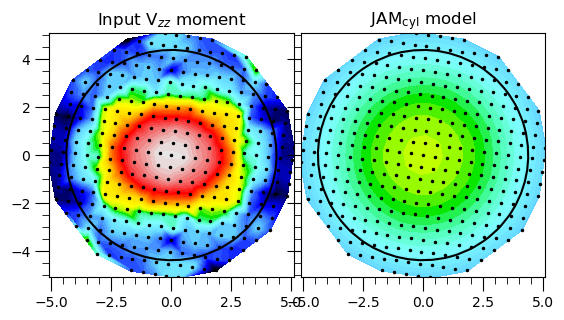

In [352]:
model =JAM_cyl([dynpop_cyl_MFL[d_idx]['beta_z'], dynpop_cyl_MFL[d_idx]['inc_deg']])

In [356]:
np.average(model/rms)

1.0179932007625447

In [357]:
dynpop_cyl[d_idx]

inc_deg,beta_z,log_ML_stellar,log_rho_s,rs,kappa,log_Mt_Re,log_Ms_Re,log_Md_Re,fdm_Re,log_ML_dyn_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,log_Ms_rhalf,log_Md_rhalf,MW_Gt_Re,MW_Gs_Re,MW_Gd_Re,MW_Gt_rhalf,MW_Gs_rhalf,MW_Gd_rhalf,Gt_Re,Gs_Re,Gd_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2.581,0.0,1.198,5.6879400086720375,250.0,-0.687,12.155,11.934,11.755,0.398,1.419,0.062845,2.7189581724958227,12.023,11.861,11.517,1.905,2.433,1.107,1.99,2.4,1.084,-1.868,-2.548,-1.097


jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.03
analytic_los=1 logistic=0 constant_anisotropy=1
inc=90.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=98.5
Total mass MGE (MSun): 1.304e+15



TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

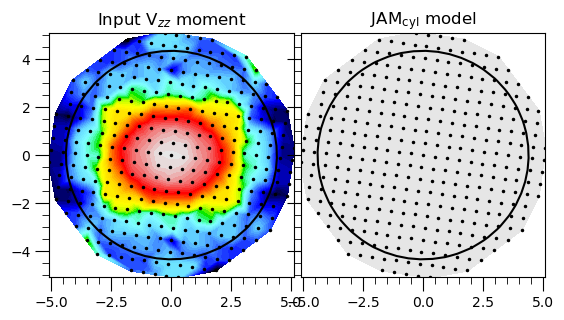

In [428]:
x0 = ([1000*dynpop_cyl[d_idx]['rs'],
       dynpop_cyl[d_idx]['fdm_Re'],
       dynpop_cyl[d_idx]['beta_z'],
       dynpop_cyl[d_idx]['inc_deg'],
      dynpop_cyl[d_idx]['log_ML_stellar']])

bounds = ([1,0,-np.inf,0, 0.1],
          [250001, 1, np.inf, 90,2])

res = least_squares(JAM_cyl_halo, x0, bounds=bounds)

jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.05
analytic_los=1 logistic=0 constant_anisotropy=1
inc=90.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=97.8
Total mass MGE (MSun): 1.284e+15



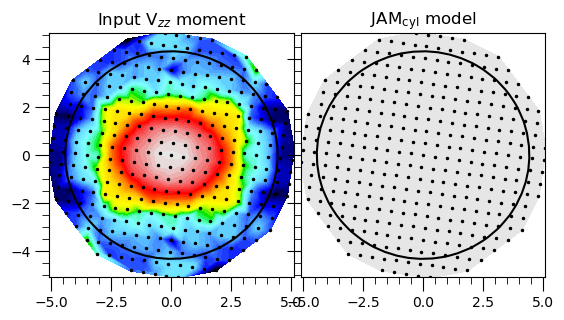

In [413]:
JAM_cyl_halo(x0)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_59309/730211133.py:4: RuntimeWarning: divide by zero encountered in log10
  AB_img = 22.5 - 2.5*np.log10(rimg)


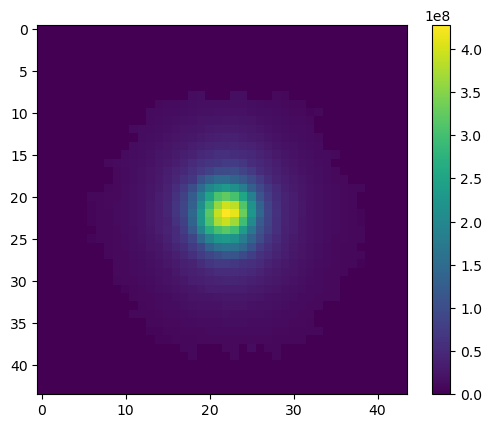

In [377]:
distance=c*z/H_0
Limg = mag_conv(rimg)
plt.imshow(Limg)
plt.colorbar()

In [379]:
np.log10(np.sum(Limg))

10.53215